# Deskripsi Data

Projek ini melakukan Market Basket Analysis pada data transaksi sebuah bakery dengan :
- Menganalisi pola pembelian berdasarkan waktu (bulan, hari, jam)
- Mengetahui produk yang paling laris
- Membangun Association Rule menggunakan Algoritma Apriori untuk melihat produk apa yang sering dibeli secara bersamaan

Struktur Dataset bakery ini berisi 5 kolom, yaitu :
- Transaction : ID transaksi
- Item : nama produk yang dibeli
- date_time : waktu transaksi dalam format string, misal 30-10-2016 09:58
- period_day : periode waktu hari, misal morning
- weekday_weekend : kategori hari kerja atau hari pekan
Dataset ini terdiri dari 20507 baris dan 5 kolom

# Import Library dan Load Data

In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

import seaborn as sns
%matplotlib inline

from mlxtend.frequent_patterns import association_rules, apriori

- Mengimpor pandas, numpy, matplotlib, seaborn untuk analisis dan visualisasi.
- Membaca dataset asli ke dalam dataframe sebagai sumber utama data. 

In [2]:
df = pd.read_csv("bread basket in london.csv")

# Data Preprocessing

In [3]:
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [5]:
print('Jumlah total transaksi', df['Transaction'].nunique())

Jumlah total transaksi 9465


In [6]:
# menghitung jumlah barang yang terjual
print('Jumlah total barang yang dijual', df['Item'].nunique())

Jumlah total barang yang dijual 94


In [7]:
# Konversikan kolom date_time ke format yang tepat agar lebih mudah diekstraksi.
df['date_time'] = pd.to_datetime(df['date_time'])
df.head()

C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\1992491444.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['date_time'])


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,2016-10-30 09:58:00,morning,weekend
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend
4,3,Jam,2016-10-30 10:07:00,morning,weekend


In [8]:
# extracting date
df['date'] = df['date_time'].dt.date

# extracting hour
df['hour'] = df['date_time'].dt.hour

# extracting month and display full name of the month
df['month'] = df['date_time'].dt.strftime('%Y-%m')

# extracting weekday and display full name of the weekday
df['weekday'] = df['date_time'].dt.strftime('%A')

# dropping date_time column as it's not necessary anymore
df.drop('date_time', axis = 1, inplace = True)

df.head()

,Transaction,Item,period_day,weekday_weekend,date,hour,month,weekday
0,1,Bread,morning,weekend,2016-10-30,9,2016-10,Sunday
1,2,Scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
2,2,Scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
3,3,Hot chocolate,morning,weekend,2016-10-30,10,2016-10,Sunday
4,3,Jam,morning,weekend,2016-10-30,10,2016-10,Sunday


In [9]:
# change the item name to lowercase and remove any spaces
df['Item'] = df['Item'].str.strip()
df['Item'] = df['Item'].str.lower()
df.head()

,Transaction,Item,period_day,weekday_weekend,date,hour,month,weekday
0,1,bread,morning,weekend,2016-10-30,9,2016-10,Sunday
1,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
2,2,scandinavian,morning,weekend,2016-10-30,10,2016-10,Sunday
3,3,hot chocolate,morning,weekend,2016-10-30,10,2016-10,Sunday
4,3,jam,morning,weekend,2016-10-30,10,2016-10,Sunday


In [10]:
df.shape

(20507, 8)

# Exploratory Data Analysis (EDA) dan Visualisasi

Bagian ini menganalisis karakteristik dataset sebelum dilakukan pemodelan.
- Melihat dimensi data, contoh data, dan kolom.
- Mengubah kolom date_time menjadi datetime.
- Membuat fitur tambahan seperti month, day, hour.
- Visualisasi item terlaris dan distribusi transaksi berdasarkan waktu.
Tujuan: memahami pola pembelian, kapan transaksi ramai, dan produk paling populer.

In [11]:
# Ganti 'Item' dengan nama kolom produk di dataset Anda
print(df['Item'].unique())

['bread' 'scandinavian' 'hot chocolate' 'jam' 'cookies' 'muffin' 'coffee'
 'pastry' 'medialuna' 'tea' 'tartine' 'basket' 'mineral water'
 'farm house' 'fudge' 'juice' "ella's kitchen pouches" 'victorian sponge'
 'frittata' 'hearty & seasonal' 'soup' 'pick and mix bowls' 'smoothies'
 'cake' 'mighty protein' 'chicken sand' 'coke' 'my-5 fruit shoot'
 'focaccia' 'sandwich' 'alfajores' 'eggs' 'brownie' 'dulce de leche'
 'honey' 'the bart' 'granola' 'fairy doors' 'empanadas' 'keeping it local'
 'art tray' 'bowl nic pitt' 'bread pudding' 'adjustment' 'truffles'
 'chimichurri oil' 'bacon' 'spread' 'kids biscuit' 'siblings'
 'caramel bites' 'jammie dodgers' 'tiffin' 'olum & polenta' 'polenta'
 'the nomad' 'hack the stack' 'bakewell' 'lemon and coconut' 'toast'
 'scone' 'crepes' 'vegan mincepie' 'bare popcorn' 'muesli' 'crisps'
 'pintxos' 'gingerbread syrup' 'panatone' 'brioche and salami'
 'afternoon with the baker' 'salad' 'chicken stew' 'spanish brunch'
 'raspberry shortbread sandwich' 'extra

In [12]:
# 1. Membuat list item yang BUKAN produk (Trash list)
# Pastikan penulisan huruf besar/kecil sama persis dengan output Anda
non_products = [
    'adjustment',
    'gift voucher',
    'postcard',
    'tshirt',
    "valentine's card",
    'nomad bag',
    'afternoon with the baker',
    'argentina night',
    'hack the stack',
    'keeping it local',
    'christmas common',
    'siblings'
]

In [13]:
# 2. Melakukan filtering
# Ambil data yang Item-nya TIDAK ada di dalam list non_products
df_clean = df[~df['Item'].isin(non_products)]

In [14]:
# 3. Verifikasi
print(f"Jumlah baris sebelum dibersihkan: {len(df)}")
print(f"Jumlah baris setelah dibersihkan: {len(df_clean)}")

Jumlah baris sebelum dibersihkan: 20507
Jumlah baris setelah dibersihkan: 20324


In [15]:
# Cek kembali apakah item pengganggu sudah hilang
print("\nSisa Item Unik (Sample):")
print(df_clean['Item'].unique()) # Menampilkan 10 item pertama saja


Sisa Item Unik (Sample):
['bread' 'scandinavian' 'hot chocolate' 'jam' 'cookies' 'muffin' 'coffee'
 'pastry' 'medialuna' 'tea' 'tartine' 'basket' 'mineral water'
 'farm house' 'fudge' 'juice' "ella's kitchen pouches" 'victorian sponge'
 'frittata' 'hearty & seasonal' 'soup' 'pick and mix bowls' 'smoothies'
 'cake' 'mighty protein' 'chicken sand' 'coke' 'my-5 fruit shoot'
 'focaccia' 'sandwich' 'alfajores' 'eggs' 'brownie' 'dulce de leche'
 'honey' 'the bart' 'granola' 'fairy doors' 'empanadas' 'art tray'
 'bowl nic pitt' 'bread pudding' 'truffles' 'chimichurri oil' 'bacon'
 'spread' 'kids biscuit' 'caramel bites' 'jammie dodgers' 'tiffin'
 'olum & polenta' 'polenta' 'the nomad' 'bakewell' 'lemon and coconut'
 'toast' 'scone' 'crepes' 'vegan mincepie' 'bare popcorn' 'muesli'
 'crisps' 'pintxos' 'gingerbread syrup' 'panatone' 'brioche and salami'
 'salad' 'chicken stew' 'spanish brunch' 'raspberry shortbread sandwich'
 'extra salami or feta' 'duck egg' 'baguette' 'vegan feast' 'chocolat

In [16]:
df_clean.shape

(20324, 8)

### Best selling items

In [17]:
# Pastikan variabel 'df_clean' sudah dibuat/dijalankan di cell sebelumnya

# 1. Hitung jumlah item terjual menggunakan 'df_clean'
# Kita ganti sumber datanya menjadi df_clean['Item']
top_items = pd.DataFrame(df_clean['Item'].value_counts(dropna=True, sort=True)).reset_index()

# 2. Ubah nama kolom menjadi 'item' dan 'count'
top_items.columns = ['item', 'count']

# 3. Hitung persentase penjualan
top_items['percentage'] = top_items['count'].apply(lambda x: x / top_items['count'].sum())

# 4. Ambil 10 produk teratas
top_10_items = top_items.head(10)

# 5. Tampilkan hasil
top_10_items

,item,count,percentage
0,coffee,5471,0.269189
1,bread,3325,0.163600
2,tea,1435,0.070606
3,cake,1025,0.050433
4,pastry,856,0.042118
5,sandwich,771,0.037935
6,medialuna,616,0.030309
7,hot chocolate,590,0.029030
8,cookies,540,0.026570
9,brownie,379,0.018648


C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\2703705142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='item', y='count', data=top_10_items, palette='viridis')


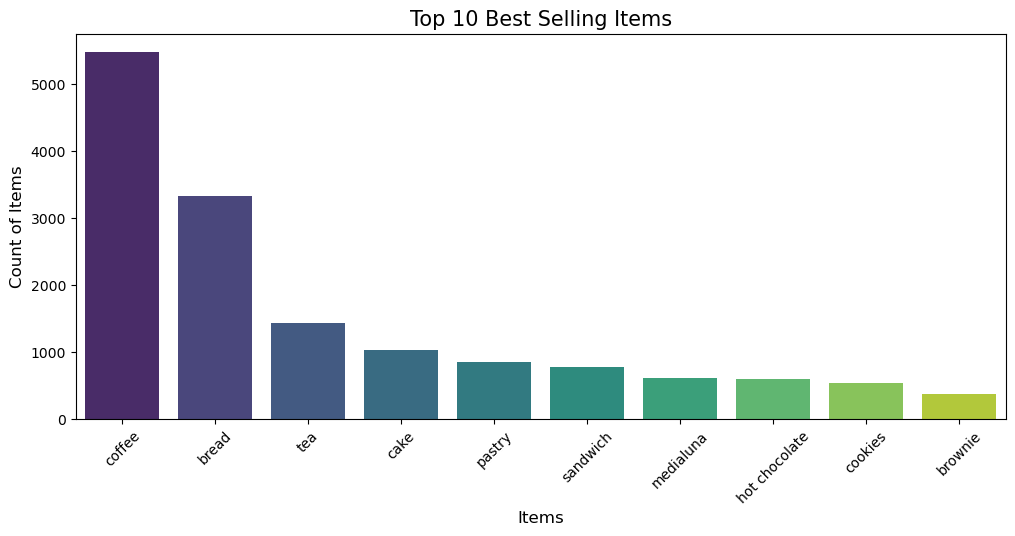

In [18]:
# Pastikan Anda menggunakan 'top_10_items' yang sudah di-filter 10 teratas
plt.figure(figsize=(12,5))
sns.barplot(x='item', y='count', data=top_10_items, palette='viridis')

plt.xlabel('Items', size=12)
plt.xticks(rotation=45)
plt.ylabel('Count of Items', size=12)
plt.title('Top 10 Best Selling Items', size=15)
plt.show()

### Number of items per transaction

In [19]:
# 1. Hitung jumlah item di setiap transaksi menggunakan data bersih ('df_clean')
items_num = df_clean.groupby('Transaction', as_index=False)['Item'].count()

# 2. Pivot table untuk menampilkan distribusi transaksi berdasarkan jumlah item
# Catatan: Di langkah ini, kolom 'Item' berisi angka jumlah barang (1, 2, 3...)
items_num = items_num.pivot_table(index='Item', values='Transaction', aggfunc='count')

# 3. Ubah nama kolom agar tidak membingungkan saat ditampilkan
# Index 'Item' sebenarnya adalah "Jumlah Barang", dan Value 'Transaction' adalah "Jumlah Transaksi"
items_num.index.name = 'Number of Items in Basket'
items_num.columns = ['Number of Transactions']

# 4. Hitung persentase
items_num['percentage'] = items_num['Number of Transactions'].apply(lambda x: x / items_num['Number of Transactions'].sum())

# 5. Tampilkan hasil
items_num

,Number of Transactions,percentage
Number of Items in Basket,,
1,3602,0.383518
2,2897,0.308454
3,1517,0.161520
4,835,0.088905
5,337,0.035882
6,133,0.014161
7,37,0.003940
8,21,0.002236
9,7,0.000745


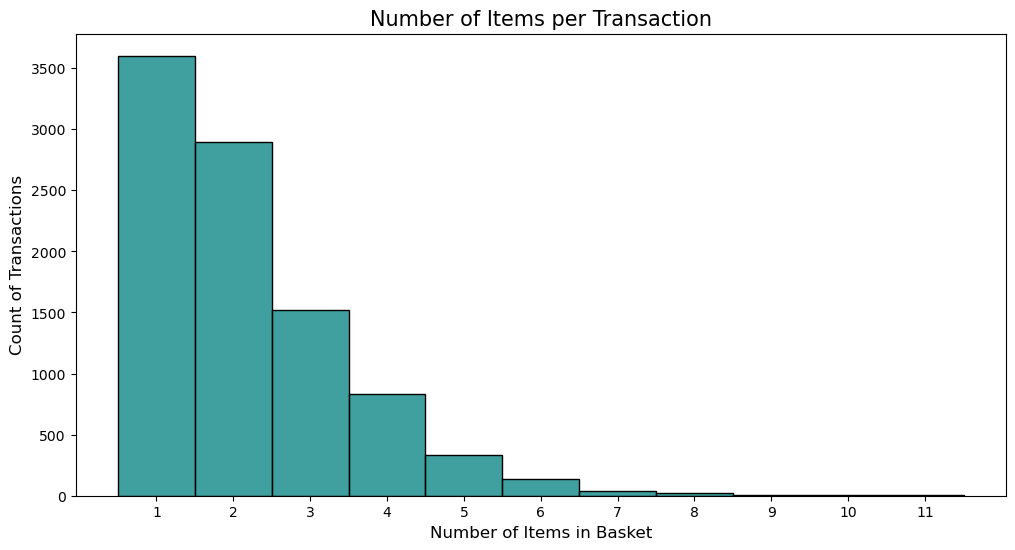

In [20]:


# Mengatur ukuran gambar agar lebih jelas
plt.figure(figsize=(12, 6))

# Cek nama kolom yang tersedia (agar kode tidak error beda versi)
col_weight = 'Number of Transactions'
if 'Number of Transactions' not in items_num.columns:
    col_weight = 'Transaction' # Fallback jika kolom belum direname

# Membuat plot
# x = index (jumlah barang: 1, 2, 3...)
# weights = frekuensi (berapa banyak transaksi yang isinya segitu)
ax = sns.histplot(x=items_num.index, weights=items_num[col_weight], discrete=True, color='teal')

# Memberi label dan judul
plt.xlabel('Number of Items in Basket', size=12)
plt.ylabel('Count of Transactions', size=12)
plt.title('Number of Items per Transaction', size=15)

# Mengatur sumbu X agar menampilkan semua angka (1, 2, 3...) tanpa koma
# Kita hanya ambil index yang ada datanya
ax.set_xticks(items_num.index)

plt.show()

### Quantity Sold by Month

In [21]:
# Hitung kuantitas item yang terjual per bulan menggunakan data bersih
# Ganti 'df' menjadi 'df_clean'
qty_month = df_clean.groupby('month', as_index=False)['Transaction'].count()
qty_month.columns = ['month', 'quantity_sold']

qty_month.head()

,month,quantity_sold
0,2016-10,369
1,2016-11,4370
2,2016-12,3337
3,2017-01,3340
4,2017-02,3843


C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\324700551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='quantity_sold', data=qty_month, palette='viridis')


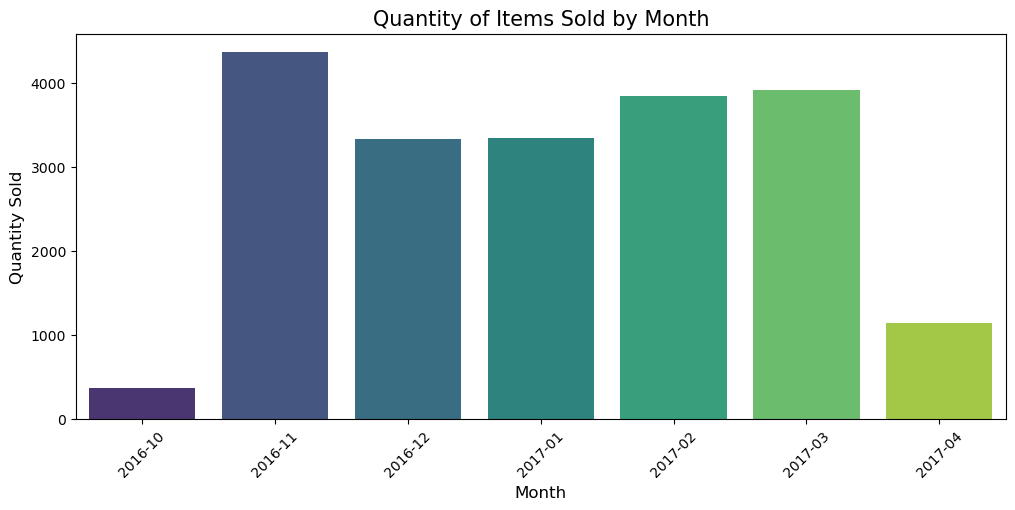

In [22]:


plt.figure(figsize=(12, 5))

# Membuat bar plot
sns.barplot(x='month', y='quantity_sold', data=qty_month, palette='viridis')

plt.xlabel('Month', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity of Items Sold by Month', size=15)
plt.xticks(rotation=45) # Memutar label bulan agar tidak bertumpuk
plt.show()

### Quantity Sold by Days of Week

In [23]:
# 1. Hitung transaksi per hari menggunakan data bersih
qty_wd = df_clean.groupby('weekday', as_index=False)['Transaction'].count()

# 2. Ganti nama kolom agar lebih jelas
qty_wd.columns = ['weekday', 'quantity_sold']

# 3. Mengurutkan hari dengan cara yang lebih aman (Categorical Sort)
# Kita tentukan urutan yang kita inginkan: Senin -> Minggu
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Mengubah kolom weekday menjadi tipe data kategori dengan urutan yang ditentukan
qty_wd['weekday'] = pd.Categorical(qty_wd['weekday'], categories=days_order, ordered=True)

# 4. Sortir berdasarkan urutan kategori tadi
qty_wd.sort_values('weekday', inplace=True)

# 5. Tampilkan hasil
qty_wd

,weekday,quantity_sold
1,Monday,2309
5,Tuesday,2375
6,Wednesday,2306
4,Thursday,2621
0,Friday,3107
2,Saturday,4537
3,Sunday,3069


C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\1816354948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weekday', y='quantity_sold', data=qty_wd, palette='viridis')


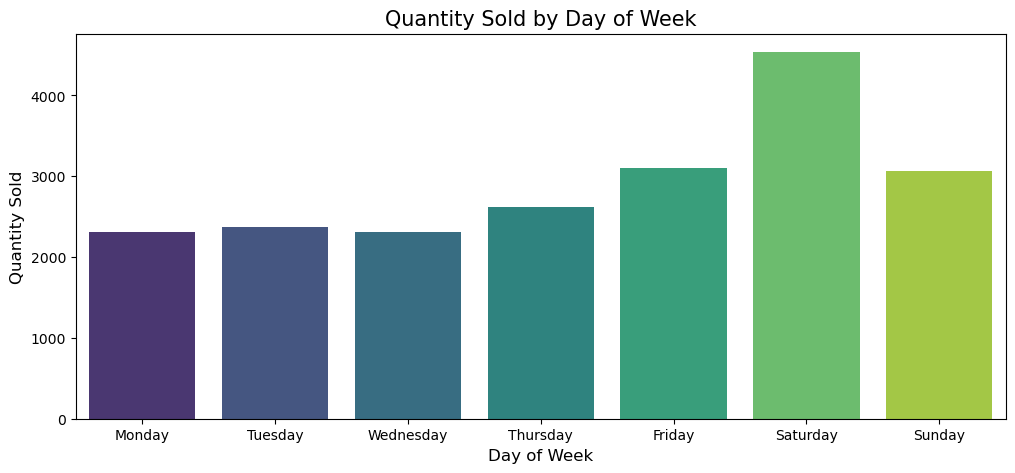

In [24]:

plt.figure(figsize=(12,5))

sns.barplot(x='weekday', y='quantity_sold', data=qty_wd, palette='viridis')

plt.xlabel('Day of Week', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity Sold by Day of Week', size=15)
plt.show()

### Quantity Sold by Hours

In [25]:
# 1. Hitung jumlah item terjual berdasarkan jam (hour) dari data bersih
# Ganti 'df' menjadi 'df_clean'
qty_hr = df_clean.groupby('hour', as_index=False)['Transaction'].count()

# 2. Rename kolom agar konsisten dan jelas
qty_hr.columns = ['hour', 'quantity_sold']

# 3. Membuat bins (opsional, tapi jika Anda ingin label interval)
# Ganti range menjadi (0, 25) agar jam 23.00 - 23.59 tetap terhitung
qty_hr['hour_bins'] = pd.cut(qty_hr['hour'], bins=range(0, 25, 1), right=False)

# 4. Tampilkan hasil
qty_hr.head()

,hour,quantity_sold,hour_bins
0,1,1,"[1, 2)"
1,7,24,"[7, 8)"
2,8,630,"[8, 9)"
3,9,1944,"[9, 10)"
4,10,2645,"[10, 11)"


C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\2217724875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='quantity_sold', data=qty_hr, palette='viridis')


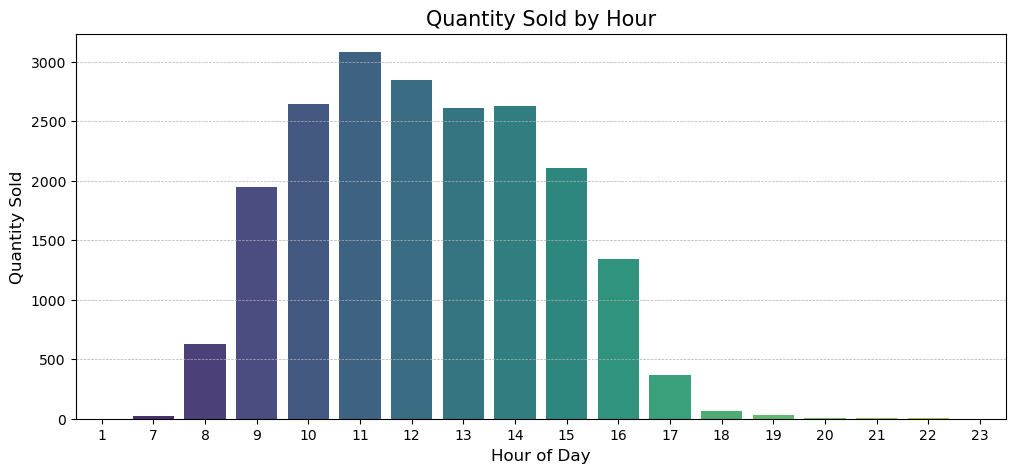

In [26]:


plt.figure(figsize=(12, 5))

# Kita gunakan 'hour' (angka) sebagai sumbu X agar lebih mudah dibaca daripada interval bins
sns.barplot(x='hour', y='quantity_sold', data=qty_hr, palette='viridis')

plt.xlabel('Hour of Day', size=12)
plt.ylabel('Quantity Sold', size=12)
plt.title('Quantity Sold by Hour', size=15)

# Menambahkan grid tipis agar mudah melihat level ketinggian batang
plt.grid(axis='y', ls='--', lw=0.5)

plt.show()

## Algoritma Apriori dengan Market Basket Analysis

In [27]:
# select only required variables for modelling
transactions = df_clean.groupby(['Transaction', 'Item'])['Item'].count().reset_index(name ='Count')
transactions.head()

,Transaction,Item,Count
0,1,bread,1
1,2,scandinavian,2
2,3,cookies,1
3,3,hot chocolate,1
4,3,jam,1


Fungsi apriori mengharapkan data masukan dalam DataFrame pandas yang dienkode one-hot, oleh karena itu, kita perlu mengubah DataFrame di atas menjadi representasi variabel kategorikal sebagai vektor biner.

In [28]:
# Membuat pivot table
# aggfunc='sum' akan menjumlahkan item (misal beli 2 roti jadi angka 2)
my_basket = transactions.pivot_table(index='Transaction', columns='Item', values='Count', aggfunc='sum').fillna(0)

# Langkah PENTING: Encoding (Mengubah semua angka > 0 menjadi 1)
# Apriori hanya butuh info "dibeli" (1) atau "tidak" (0), tidak peduli jumlahnya.
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

# Terapkan fungsi encoding
my_basket = my_basket.applymap(encode_units)

# Tampilkan hasilnya
my_basket.head()

C:\Users\Andini\AppData\Local\Temp\ipykernel_6264\671920862.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  my_basket = my_basket.applymap(encode_units)


Item,alfajores,art tray,bacon,baguette,bakewell,bare popcorn,basket,bowl nic pitt,bread,bread pudding,...,tartine,tea,the bart,the nomad,tiffin,toast,truffles,vegan feast,vegan mincepie,victorian sponge
Transaction,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Minimun sippport adalah ambang batas frekuensi atau kemunculan minimum yang harus dipenuhi oleh suatu itemset agar dianggap sering muncul.

suatu itemset dianggap sering muncul jika muncul setidaknya 1% dari total jumlah transaksi (1% dari 9465).

In [29]:
# create frequent items df with itemsets and support columns by using `apriori` function
frequent_items = apriori(my_basket, min_support = 0.01, use_colnames = True)
frequent_items

C:\Users\Andini\anaconda3\envs\proyek_cv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.036627,(alfajores)
1,0.016184,(baguette)
2,0.329749,(bread)
3,0.040353,(brownie)
4,0.104664,(cake)
...,...,...
56,0.023850,"(toast, coffee)"
57,0.014480,"(tea, sandwich)"
58,0.010115,"(bread, cake, coffee)"
59,0.011286,"(bread, coffee, pastry)"


Lift menunjukkan berapa kali A dan B benar-benar muncul dalam urutan yang sama, dibandingkan jika tidak ada hubungan di antara keduanya. Dengan kata lain, ia memperhitungkan dukungan dari setiap item untuk mengukur kekuatan asosiasi di antara keduanya. Nilai lift 1 berarti tidak ada asosiasi antara kedua item tersebut. Nilai lift lebih besar dari 1 berarti kedua item tersebut berasosiasi positif, artinya kehadiran satu item meningkatkan kemungkinan kehadiran item lainnya.

Proyek ini akan menetapkan ambang batas minimum untuk metrik lift menjadi 1,2 untuk mengembalikan aturan asosiasi yang terjadi setidaknya 20% lebih sering daripada yang kita harapkan jika terjadi secara acak.

In [30]:
# create the rules from frequent itemset generated above with min lift = 1.2
# nilai lift untuk matriks
metric = "lift"
min_threshold = 1.2

rules = association_rules(frequent_items, metric = metric, min_threshold = min_threshold)[["antecedents", "consequents", "support", "confidence", "lift"]]
rules.sort_values('confidence', ascending = False, inplace = True)
rules.reset_index(drop=True, inplace = True)
rules

#jika membeli toast maka membeli coffee nilai supportnya sekian
#melihat nilai dari associationnya

,antecedents,consequents,support,confidence,lift
0,(toast),(coffee),0.023850,0.704403,1.461075
1,(spanish brunch),(coffee),0.010967,0.598837,1.242111
2,(cake),(tea),0.023957,0.228891,1.592404
3,"(tea, coffee)",(cake),0.010115,0.201271,1.923031
4,(sandwich),(tea),0.014480,0.200000,1.391407
5,(hot chocolate),(cake),0.011499,0.195652,1.869344
6,"(cake, coffee)",(tea),0.010115,0.183398,1.275904
7,(tea),(cake),0.023957,0.166667,1.592404
8,(pastry),"(bread, coffee)",0.011286,0.130061,1.433728
9,"(bread, coffee)",(pastry),0.011286,0.124413,1.433728


## Parallel coordinates plot

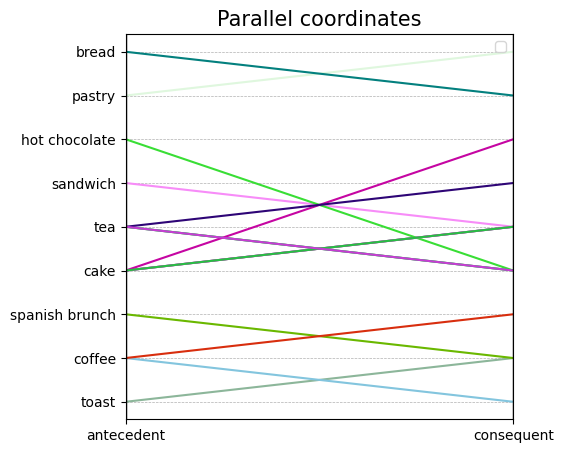

In [31]:
# Function to convert rules to coordinates.
def rules_to_coordinates(rules):
    rules['antecedent'] = rules['antecedents'].apply(lambda antecedent: list(antecedent)[0])
    rules['consequent'] = rules['consequents'].apply(lambda consequent: list(consequent)[0])
    rules['rule'] = rules.index
    return rules[['antecedent','consequent','rule']]

# import sub lib to plot parallel coordinates
from pandas.plotting import parallel_coordinates

# Convert rules into coordinates suitable for use in a parallel coordinates plot
coords = rules_to_coordinates(rules)

# Generate parallel coordinates plot
plt.figure(figsize=(5,5))
parallel_coordinates(coords, 'rule')
plt.legend([])
plt.grid(ls='--', lw='0.5')
plt.title('Parallel coordinates', size = 15)
plt.show()

## Itemsets Lift Heatmap

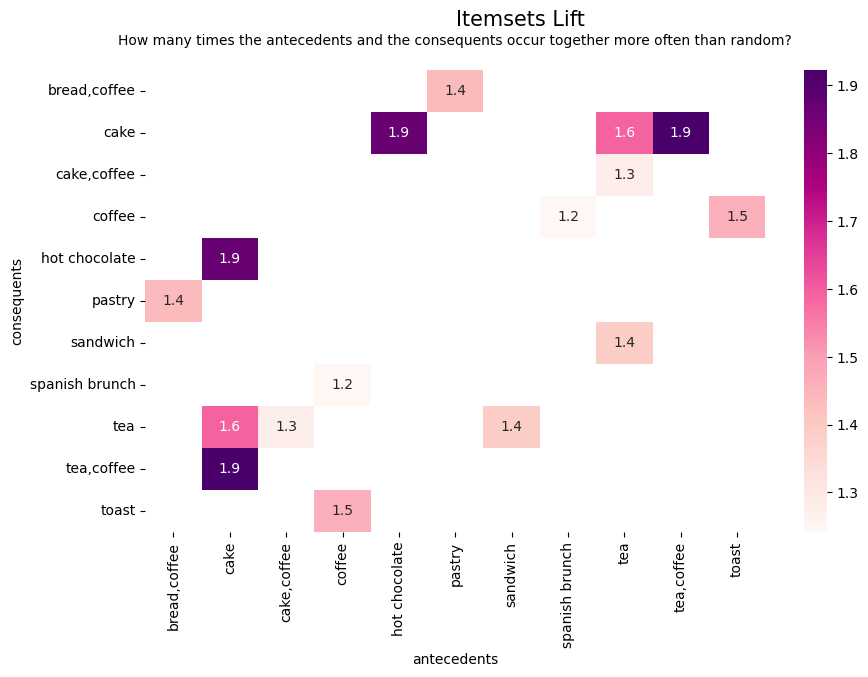

In [32]:
# convert antecedents and consequents into strings
rules['antecedents'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
rules['consequents'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

# transform antecedent, consequent, and support columns into matrix
support_table_lift = rules.pivot(index='consequents', columns='antecedents', values='lift')

# generate a heatmap with annotations 
plt.figure(figsize=(10,6))
sns.heatmap(support_table_lift, annot = True, cbar = True, cmap="RdPu")
plt.suptitle('Itemsets Lift', size = 15)
plt.title('How many times the antecedents and the consequents occur together more often than random?\n', size=10)
plt.show()

## Itemsets Confidence Heatmap

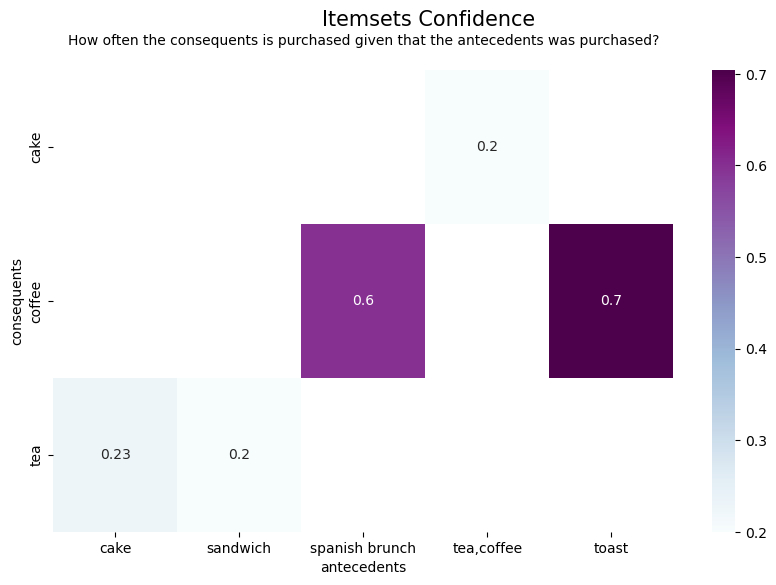

In [33]:
# transform antecedent, consequent, and support columns into matrix
rules_confidence = rules[rules['confidence']>=0.2] # select min lift=1.2
support_table_conf = rules_confidence.pivot(index='consequents', columns='antecedents', values='confidence')

# generate a heatmap with annotations
plt.figure(figsize=(10,6))
sns.heatmap(support_table_conf, annot = True, cbar = True, cmap="BuPu")
plt.suptitle('Itemsets Confidence', size = 15)
plt.title('How often the consequents is purchased given that the antecedents was purchased?\n', size = 10)
plt.show()

## Implementasi Apriori cuci gudang

In [34]:
# 1. ANALISIS PERFORMA PRODUK (Gunakan df_clean!)
# Hitung total penjualan per item dari data bersih
product_counts = df_clean['Item'].value_counts().reset_index()
product_counts.columns = ['Produk', 'Jumlah_Terjual']

In [35]:
# 2. Menentukan Threshold (Batas)
# Fast Moving: Top 20% produk terlaris (Pareto Principle)
# Slow Moving: Bottom 40% produk (jarang laku)
threshold_fast = product_counts['Jumlah_Terjual'].quantile(0.80)
threshold_slow = product_counts['Jumlah_Terjual'].quantile(0.40)

fast_moving = product_counts[product_counts['Jumlah_Terjual'] >= threshold_fast]
slow_moving = product_counts[product_counts['Jumlah_Terjual'] <= threshold_slow]

print(f"--- STATISTIK ---")
print(f"Batas Penjualan Fast Moving: > {threshold_fast:.0f} item")
print(f"Batas Penjualan Slow Moving: < {threshold_slow:.0f} item")
print(f"Jumlah Produk Fast Moving (Hero): {len(fast_moving)} item")
print(f"Jumlah Produk Slow Moving (Target Cuci Gudang): {len(slow_moving)} item")
print(f"Top 3 Hero Products: {fast_moving.head(3)['Produk'].tolist()}")

--- STATISTIK ---
Batas Penjualan Fast Moving: > 310 item
Batas Penjualan Slow Moving: < 11 item
Jumlah Produk Fast Moving (Hero): 17 item
Jumlah Produk Slow Moving (Target Cuci Gudang): 33 item
Top 3 Hero Products: ['coffee', 'bread', 'tea']


In [36]:
# 3. ALGORITMA BUNDLING (Strategy Engine)
bundles = []
# Ambil 3 produk teratas sebagai "Penarik" (Anchor)
top_heroes = fast_moving.head(3)['Produk'].tolist() 

# Iterasi produk yang kurang laku untuk dipasangkan
for i, row_slow in slow_moving.iterrows():
    # Rotasi Hero Product agar variatif (Misal: Coffee, lalu Bread, lalu Tea, balik ke Coffee...)
    hero_selected = top_heroes[i % len(top_heroes)] 
    
    produk_cuci = row_slow['Produk']
    stok_terjual = row_slow['Jumlah_Terjual']
    
    bundles.append({
        'Hero_Product': hero_selected,
        'Produk_Cuci_Gudang': produk_cuci,
        'Histori_Penjualan_Slow_Item': stok_terjual,
        'Strategi_Marketing': f"Bundling: Beli {hero_selected}, Tebus Murah {produk_cuci}"
    })

In [37]:
# 4. SIMPAN HASIL
df_rekomendasi = pd.DataFrame(bundles)

# Menampilkan 10 rekomendasi teratas di layar
print("\n=== CONTOH REKOMENDASI PAKET CUCI GUDANG ===")
print(df_rekomendasi[['Hero_Product', 'Produk_Cuci_Gudang', 'Strategi_Marketing']])


=== CONTOH REKOMENDASI PAKET CUCI GUDANG ===
   Hero_Product             Produk_Cuci_Gudang  \
0         bread                   tacos/fajita   
1           tea                 mighty protein   
2        coffee                     chocolates   
3         bread              gingerbread syrup   
4           tea      drinking chocolate spoons   
5        coffee                         muesli   
6         bread                coffee granules   
7           tea               victorian sponge   
8        coffee                      empanadas   
9         bread                         crepes   
10          tea             half slice monster   
11       coffee                        pintxos   
12        bread              lemon and coconut   
13          tea                          honey   
14       coffee                         basket   
15        bread                   bare popcorn   
16          tea                       panatone   
17       coffee                       mortimer   
18  

## Cross Selling

In [38]:
print("Sedang menghitung interaksi produk (Perbaikan Rumus Probabilitas)...")

bundles_final = []
hero_products_list = fast_moving['Produk'].tolist()

# Loop untuk setiap barang Slow Moving
for i, row_slow in slow_moving.iterrows():
    produk_slow = row_slow['Produk']
    
    # 1. Cari Nomor Transaksi yang memuat produk Slow ini
    transaksi_dengan_slow = df_clean[df_clean['Item'] == produk_slow]['Transaction'].unique()
    total_transaksi_slow = len(transaksi_dengan_slow)
    
    # 2. Cari Hero Product yang muncul di transaksi-transaksi tersebut
    irisan_data = df_clean[
        (df_clean['Transaction'].isin(transaksi_dengan_slow)) & 
        (df_clean['Item'].isin(hero_products_list))
    ]
    
    if not irisan_data.empty:
        # PERBAIKAN DI SINI:
        # Hitung jumlah TRANSAKSI UNIK di mana Hero muncul (bukan jumlah item)
        # Agar nilai tidak lebih dari 1.0
        hero_counts = irisan_data.groupby('Item')['Transaction'].nunique()
        
        # Ambil Hero dengan frekuensi transaksi terbanyak
        best_hero = hero_counts.idxmax()
        jumlah_transaksi_bareng = hero_counts.max()
        
        # Rumus Probabilitas: (Struk bareng) / (Total struk slow)
        probabilitas = round(jumlah_transaksi_bareng / total_transaksi_slow, 2)
        
        metode = 'Data Driven'
        alasan = f"Dibeli bareng di {jumlah_transaksi_bareng} dari {total_transaksi_slow} transaksi"
        
    else:
        # Fallback ke Rotasi Manual jika tidak ada irisan sama sekali
        best_hero = hero_products_list[i % len(hero_products_list)]
        metode = 'Manual Rotation'
        probabilitas = 0.00
        alasan = "Tidak ada riwayat transaksi bersama"

    # Simpan Hasil
    bundles_final.append({
        'Slow_Product': produk_slow,
        'Pasangan_Hero': best_hero,
        'Metode': metode,
        'Peluang_Terjual': probabilitas, 
        'Detail_Alasan': alasan,
        'Rekomendasi_Marketing': f"Beli {best_hero}, Diskon 50% {produk_slow}"
    })

# --- TAMPILKAN HASIL FINAL ---
df_rekomendasi_final = pd.DataFrame(bundles_final)

# Urutkan berdasarkan peluang tertinggi
df_rekomendasi_final.sort_values(by=['Peluang_Terjual'], ascending=False, inplace=True)

print("\n=== REKOMENDASI STRATEGI BUNDLING FINAL ===")
cols_to_show = ['Pasangan_Hero', 'Slow_Product', 'Metode', 'Peluang_Terjual', 'Detail_Alasan']
print(df_rekomendasi_final[cols_to_show].head(15).to_string(index=False))

Sedang menghitung interaksi produk (Perbaikan Rumus Probabilitas)...

=== REKOMENDASI STRATEGI BUNDLING FINAL ===
Pasangan_Hero                  Slow_Product      Metode  Peluang_Terjual                        Detail_Alasan
        bread                olum & polenta Data Driven             1.00  Dibeli bareng di 1 dari 1 transaksi
          tea                      raw bars Data Driven             1.00  Dibeli bareng di 1 dari 1 transaksi
       coffee                         bacon Data Driven             1.00  Dibeli bareng di 1 dari 1 transaksi
          tea                       polenta Data Driven             1.00  Dibeli bareng di 1 dari 1 transaksi
       coffee                 bread pudding Data Driven             1.00  Dibeli bareng di 4 dari 4 transaksi
       coffee                 bowl nic pitt Data Driven             1.00  Dibeli bareng di 2 dari 2 transaksi
        bread                      the bart Data Driven             1.00  Dibeli bareng di 1 dari 1 transaksi
      

In [39]:


print("Sedang menghitung interaksi produk dengan Metrik LIFT...")

bundles_final = []
hero_products_list = fast_moving['Produk'].tolist()
total_seluruh_transaksi = df_clean['Transaction'].nunique() # Penting untuk rumus Lift

# Pre-calculate support untuk semua Hero agar cepat
hero_support_dict = {}
for h in hero_products_list:
    n_trans = df_clean[df_clean['Item'] == h]['Transaction'].nunique()
    hero_support_dict[h] = n_trans / total_seluruh_transaksi

# Loop untuk setiap barang Slow Moving
for i, row_slow in slow_moving.iterrows():
    produk_slow = row_slow['Produk']
    
    # 1. Cari Nomor Transaksi yang memuat produk Slow ini
    transaksi_dengan_slow = df_clean[df_clean['Item'] == produk_slow]['Transaction'].unique()
    total_transaksi_slow = len(transaksi_dengan_slow)
    
    # 2. Cari Hero Product yang muncul di transaksi-transaksi tersebut
    irisan_data = df_clean[
        (df_clean['Transaction'].isin(transaksi_dengan_slow)) & 
        (df_clean['Item'].isin(hero_products_list))
    ]
    
    if not irisan_data.empty:
        # Hitung kemunculan bareng
        hero_counts = irisan_data.groupby('Item')['Transaction'].nunique()
        
        # --- PERBAIKAN UTAMA: Evaluasi Semua Kandidat Hero, Bukan Cuma 1 ---
        candidates = []
        for hero_name, count_together in hero_counts.items():
            # a. Confidence (Peluang Terjual seperti kode Anda)
            confidence = count_together / total_transaksi_slow
            
            # b. Lift (Kekuatan Hubungan)
            # Rumus: Confidence / Support(Hero)
            support_hero = hero_support_dict[hero_name]
            lift = confidence / support_hero
            
            candidates.append({
                'Hero': hero_name,
                'Confidence': confidence,
                'Lift': lift,
                'Count': count_together
            })
        
        # Urutkan kandidat berdasarkan LIFT (Bukan cuma jumlah transaksi)
        # Lift > 1 berarti hubungan positif kuat
        candidates.sort(key=lambda x: x['Lift'], reverse=True)
        
        # Ambil yang Lift-nya paling tinggi sebagai pasangan terbaik
        best_match = candidates[0]
        
        bundles_final.append({
            'Slow_Product': produk_slow,
            'Pasangan_Hero': best_match['Hero'],
            'Metode': 'Data Driven (High Lift)',
            'Peluang_Terjual': round(best_match['Confidence'], 2),
            'Lift_Score': round(best_match['Lift'], 2),
            'Detail_Alasan': f"Lift {round(best_match['Lift'], 2)}x (Lebih kuat dari acak). Bareng: {best_match['Count']}x",
            'Rekomendasi_Marketing': f"Beli {best_match['Hero']}, Diskon 50% {produk_slow}"
        })
        
    else:
        # Fallback
        best_hero = hero_products_list[i % len(hero_products_list)]
        bundles_final.append({
            'Slow_Product': produk_slow,
            'Pasangan_Hero': best_hero,
            'Metode': 'Manual Rotation',
            'Peluang_Terjual': 0.00,
            'Lift_Score': 0.00,
            'Detail_Alasan': "Tidak ada riwayat bersama, dipasangkan manual",
            'Rekomendasi_Marketing': f"Bundle Hemat: {best_hero} + {produk_slow}"
        })

# --- TAMPILKAN HASIL ---
df_rekomendasi_final = pd.DataFrame(bundles_final)

# Urutkan: Prioritaskan yang Metode Data Driven & Lift Tinggi
df_rekomendasi_final.sort_values(by=['Lift_Score', 'Peluang_Terjual'], ascending=False, inplace=True)

print("\n=== REKOMENDASI STRATEGI BUNDLING (ENHANCED) ===")
cols_to_show = ['Pasangan_Hero', 'Slow_Product', 'Lift_Score', 'Peluang_Terjual', 'Detail_Alasan']
print(df_rekomendasi_final[cols_to_show].head(15).to_string(index=False))

Sedang menghitung interaksi produk dengan Metrik LIFT...

=== REKOMENDASI STRATEGI BUNDLING (ENHANCED) ===
Pasangan_Hero                  Slow_Product  Lift_Score  Peluang_Terjual                                  Detail_Alasan
        juice                         bacon       25.73             1.00 Lift 25.73x (Lebih kuat dari acak). Bareng: 1x
         soup                 bowl nic pitt       14.40             0.50  Lift 14.4x (Lebih kuat dari acak). Bareng: 1x
   farm house               chimichurri oil       12.66             0.50 Lift 12.66x (Lebih kuat dari acak). Bareng: 1x
        juice                    chocolates       11.44             0.44 Lift 11.44x (Lebih kuat dari acak). Bareng: 4x
        juice                  bare popcorn       10.29             0.40 Lift 10.29x (Lebih kuat dari acak). Bareng: 2x
        toast         cherry me dried fruit        9.84             0.33  Lift 9.84x (Lebih kuat dari acak). Bareng: 1x
        scone            brioche and salami        9.